# Diagnóstico de NTT DATA como empleador

## 0. Contexto y objetivo de negocio

Analizar las reseñas de Glassdoor para identificar fortalezas, áreas de mejora y posibles motivos de salida de NTT DATA. El resultado será un máximo de **tres acciones concretas para RRHH**, apoyadas en la comparación con peers y en rating y recomendación. El análisis es descriptivo y no demuestra causalidad.

**Peers:** Capgemini, Cognizant-Technology-Solutions, Atos y DXC-Technology. El listado del profesor sitúa a las cinco empresas en servicios TI y outsourcing tecnológico; compartir sector no garantiza tamaños ni composición geográfica comparables.

**Datos:** `df_full` conservará todas las reseñas de las cinco empresas; `df_nlp` será una muestra de hasta 2.000 por empresa para las tareas costosas.

**Referencia principal:** `Caso_Practico_NLP_Glassdoor_RRHH.pdf` (ventana indicada: julio de 2018 a julio de 2023).


## 1. Configuración

### 1.1. Imports

Ejecutar desde la carpeta del proyecto, con las dependencias y PyTorch instalados.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import seaborn as sns
import torch


### 1.2. Empresas, rutas y parámetros

Semilla fija; el límite de 2.000 reseñas se aplicará solo a `df_nlp`. Lote inicial de 16 textos, ajustable según la memoria disponible.


In [2]:
SEED = 42
MAX_REVIEWS_PER_COMPANY = 2_000
NLP_BATCH_SIZE = 16

TARGET = "NTT-DATA"
PEERS = ["Capgemini", "Cognizant-Technology-Solutions", "Atos", "DXC-Technology"]
FIRMS = [TARGET] + PEERS

BASE_DIR = Path.cwd()
PARQUET_PATH = BASE_DIR / "glassdoor_reviews_hr.parquet"
COMPANY_LIST_PATH = BASE_DIR / "lista_con_sector.xlsx"
STATEMENT_PATH = BASE_DIR / "Caso_Practico_NLP_Glassdoor_RRHH.pdf"

random.seed(SEED)
np.random.seed(SEED)

### 1.3. Opciones generales

Tablas acotadas y estilo gráfico común.


In [3]:
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110})

### 1.4. CPU/GPU

CUDA permite usar la GPU NVIDIA; se selecciona CPU si no está disponible. Las semillas no garantizan resultados idénticos entre equipos.


In [4]:
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")


Dispositivo: cuda


## 2. Carga y preparación

### 2.1. Lectura filtrada

Cargamos solo NTT DATA y sus cuatro peers en `df_full`, sin muestrear.

In [5]:
df_full = pd.read_parquet(PARQUET_PATH, engine="pyarrow", filters=[("firm", "in", FIRMS)])
print(f"Dimensiones: {df_full.shape[0]:,} reseñas y {df_full.shape[1]} columnas")
df_full["firm"].value_counts().reindex(FIRMS).to_frame("Reseñas")

Dimensiones: 104,469 reseñas y 7 columnas


,Reseñas
firm,
NTT-DATA,4423
Capgemini,26815
Cognizant-Technology-Solutions,50877
Atos,4876
DXC-Technology,17478


### 2.2. Inspección inicial

Revisamos tipos, nulos, duplicados exactos y ejemplos de texto.

In [6]:
display(pd.DataFrame({"Tipo": df_full.dtypes.astype(str), "Nulos": df_full.isna().sum()}))
print(f"Duplicados exactos: {df_full.duplicated().sum():,}")
df_full[["current", "pros", "cons"]].head(3)

,Tipo,Nulos
firm,str,0
date_review,object,0
current,str,0
overall_rating,float64,0
recommend,str,0
pros,str,0
cons,str,0


Duplicados exactos: 0


,current,pros,cons
0,Current Employee,"Working from 5 years.. But, I dont find any Pros. Pls dont join.",Very very dirty politics. You dont have any carrier growth. DONT JOIN.
1,"Current Employee, more than 1 year",Good company for freshness and experience,cab issue they provide only once side cab in shift.
2,"Current Employee, more than 3 years",best place to work\r\nflexible and friendly working environment,slow growth for freshers\r\ntransport issues for new location


### 2.3. Fechas y textos

Convertimos fechas y normalizamos espacios. Conservamos puntuación, mayúsculas y expresiones como «No cons» para no alterar su significado.

In [7]:
df_full["date_review"] = pd.to_datetime(df_full["date_review"])
df_full["anio"] = df_full["date_review"].dt.year

for col in ["pros", "cons"]:
    df_full[col] = df_full[col].astype("string").str.replace(r"\s+", " ", regex=True).str.strip().replace("", pd.NA)

df_full["date_review"].agg(["min", "max"]).to_frame("Fecha")

,Fecha
min,2018-07-27
max,2023-07-06


### 2.4. Situación laboral y antigüedad

Separamos actuales y antiguos. La antigüedad conserva el intervalo original; cuando no se informa queda ausente.

In [8]:
df_full["situacion"] = df_full["current"].str.extract(r"^(Current|Former) Employee", expand=False).map({"Current": "Actual", "Former": "Antiguo"})
df_full["antiguedad"] = df_full["current"].str.extract(r",\s*(.+)$", expand=False)

df_full[["current", "situacion", "antiguedad"]].drop_duplicates().sort_values(["situacion", "antiguedad"])

,current,situacion,antiguedad
16,"Current Employee, less than 1 year",Actual,less than 1 year
1,"Current Employee, more than 1 year",Actual,more than 1 year
86,"Current Employee, more than 10 years",Actual,more than 10 years
2,"Current Employee, more than 3 years",Actual,more than 3 years
14,"Current Employee, more than 5 years",Actual,more than 5 years
52,"Current Employee, more than 8 years",Actual,more than 8 years
0,Current Employee,Actual,NaN
4,"Former Employee, less than 1 year",Antiguo,less than 1 year
28,"Former Employee, more than 1 year",Antiguo,more than 1 year
41,"Former Employee, more than 10 years",Antiguo,more than 10 years


### 2.5. Recomendación

Traducimos `v` a «Sí», `x` a «No» y `o` a «Sin opinión», sin equiparar esta última con una respuesta negativa.

In [9]:
df_full["recomienda"] = df_full["recommend"].map({"v": "Sí", "x": "No", "o": "Sin opinión"})
df_full[["recommend", "recomienda"]].drop_duplicates()

,recommend,recomienda
0,x,No
1,v,Sí
4,o,Sin opinión


### 2.6. Datos preparados

No se han eliminado reseñas: la lectura contiene 104.469 registros, sin nulos en las columnas originales ni duplicados exactos. Los textos preparados y las variables derivadas quedan disponibles para el EDA.

In [10]:
df_actuales = df_full.loc[df_full["situacion"].eq("Actual")].copy()
df_antiguos = df_full.loc[df_full["situacion"].eq("Antiguo")].copy()

df_full[["firm", "date_review", "situacion", "antiguedad", "overall_rating", "recomienda", "pros", "cons"]].head(3)

,firm,date_review,situacion,antiguedad,overall_rating,recomienda,pros,cons
0,Atos,2018-07-27,Actual,NaN,1.0,No,"Working from 5 years.. But, I dont find any Pros. Pls dont join.",Very very dirty politics. You dont have any carrier growth. DONT JOIN.
1,Atos,2018-07-28,Actual,more than 1 year,5.0,Sí,Good company for freshness and experience,cab issue they provide only once side cab in shift.
2,Atos,2018-07-28,Actual,more than 3 years,4.0,Sí,best place to work flexible and friendly working environment,slow growth for freshers transport issues for new location


## 3. EDA

Usamos todas las reseñas de `df_full`. La referencia de peers es la media simple por empresa, sin ponderar por número de reseñas.

### 3.1. Volumen y resumen por empresa

«Sí (%)» usa todas las reseñas; «Sí con opinión (%)» excluye «Sin opinión».

In [11]:
resumen = (
    df_full.assign(si=df_full["recomienda"].eq("Sí"),
                   sin_opinion=df_full["recomienda"].eq("Sin opinión"),
                   actual=df_full["situacion"].eq("Actual"))
    .groupby("firm").agg(Reseñas=("firm", "size"), Rating=("overall_rating", "mean"),
                         **{"Sí (%)": ("si", "mean"), "Sin opinión (%)": ("sin_opinion", "mean"),
                            "Actuales (%)": ("actual", "mean")})
    .reindex(FIRMS)
)
resumen[["Sí (%)", "Sin opinión (%)", "Actuales (%)"]] *= 100
resumen["Sí con opinión (%)"] = 100 * resumen["Sí (%)"] / (100 - resumen["Sin opinión (%)"])

ETIQUETAS = dict(zip(FIRMS, ["NTT DATA", "Capgemini", "Cognizant", "Atos", "DXC Technology"]))
COLORES = dict(zip(FIRMS, ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#555555"]))
resumen.rename(index=ETIQUETAS).round(2)

,Reseñas,Rating,Sí (%),Sin opinión (%),Actuales (%),Sí con opinión (%)
firm,,,,,,
NTT DATA,4423,3.65,47.28,32.62,67.60,70.17
Capgemini,26815,3.87,59.48,26.66,76.86,81.10
Cognizant,50877,3.77,45.93,38.98,67.96,75.28
Atos,4876,3.54,43.79,34.91,65.36,67.27
DXC Technology,17478,3.29,37.64,32.52,64.53,55.78


**Lectura para RRHH.** NTT DATA dispone de 4.423 reseñas; Cognizant aporta el 48,7% del conjunto. Comparar indicadores por empresa evita confundir volumen de reseñas con una mayor representatividad de toda la plantilla.

### 3.2. Rating: ¿cómo se posiciona NTT DATA?

Rating medio en la escala de 1 a 5; la línea indica la media de los cuatro peers.

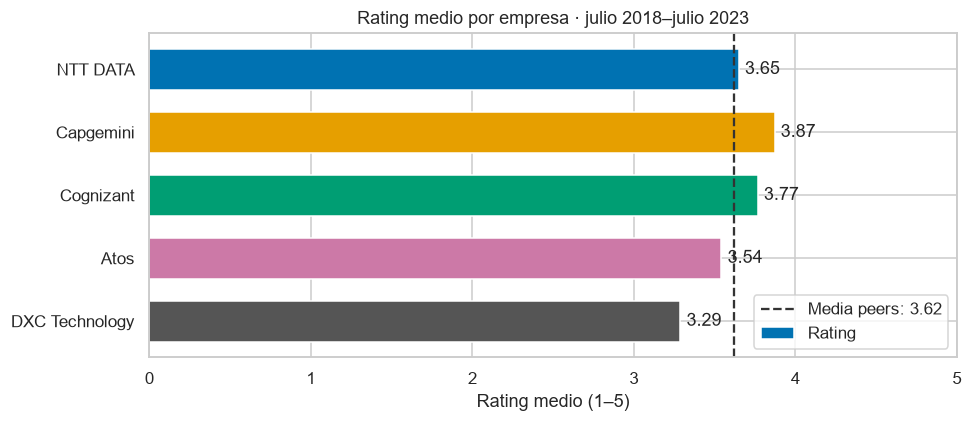

In [12]:
media_rating_peers = resumen.loc[PEERS, "Rating"].mean()
ax = resumen["Rating"].rename(index=ETIQUETAS).plot.barh(
    color=[COLORES[firm] for firm in FIRMS], figsize=(9, 4), width=0.65
)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=4)
ax.axvline(media_rating_peers, color="#333333", linestyle="--", label=f"Media peers: {media_rating_peers:.2f}")
ax.set(title="Rating medio por empresa · julio 2018–julio 2023", xlabel="Rating medio (1–5)", ylabel="", xlim=(0, 5))
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lectura para RRHH.** NTT DATA registra 3,65 frente a 3,62 de media de peers, pero queda por debajo de Capgemini (3,87) y Cognizant (3,77). El NLP deberá localizar qué fortalezas y quejas acompañan estas diferencias descriptivas antes de proponer acciones.

### 3.3. Recomendación: ¿qué proporción respalda a la empresa?

Las tres respuestas suman el 100% de las reseñas de cada empresa; «Sin opinión» se mantiene separada de «No».

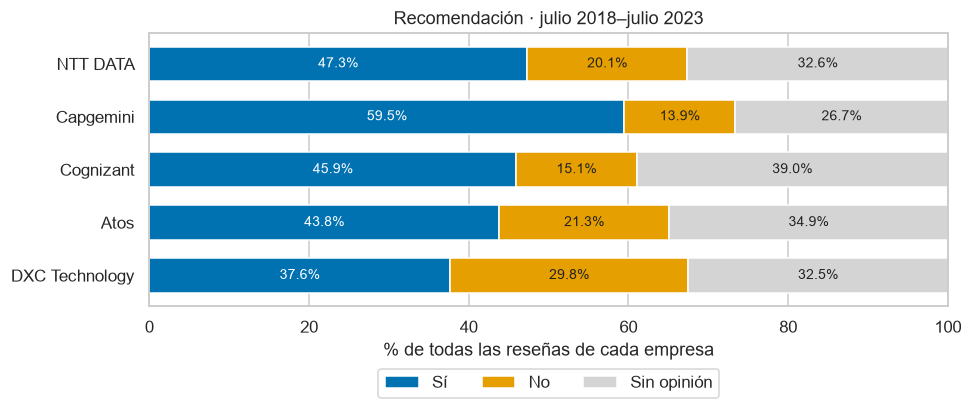

In [13]:
recomendacion_pct = pd.crosstab(df_full["firm"], df_full["recomienda"], normalize="index").mul(100)
recomendacion_pct = recomendacion_pct.reindex(index=FIRMS, columns=["Sí", "No", "Sin opinión"])
ax = recomendacion_pct.rename(index=ETIQUETAS).plot.barh(
    stacked=True, color=["#0072B2", "#E69F00", "#D4D4D4"], figsize=(9, 4), width=0.65
)
for container, color in zip(ax.containers, ["white", "#222222", "#222222"]):
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9, color=color)
ax.set(title="Recomendación · julio 2018–julio 2023", xlabel="% de todas las reseñas de cada empresa", ylabel="", xlim=(0, 100))
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout()
plt.show()

**Lectura para RRHH.** En NTT DATA, el 47,3% recomienda y el 32,6% no opina: entre quienes opinan recomienda el 70,2%. Cognizant pasa del 45,9% sobre todas sus reseñas al 75,3% entre quienes opinan; RRHH debe mantener el mismo denominador al comparar empleadores.

### 3.4. Actuales y antiguos: ¿cambia la composición y el rating?

Mostramos el peso de cada grupo, su rating y el número de reseñas que respalda cada media.

Reseñas         Rating        
situacion       Actual Antiguo Actual Antiguo
firm                                         
NTT DATA          2990    1433   3.77    3.39
Capgemini        20609    6206   3.99    3.46
Cognizant        34577   16300   3.83    3.63
Atos              3187    1689   3.69    3.26
DXC Technology   11278    6200   3.44    3.01

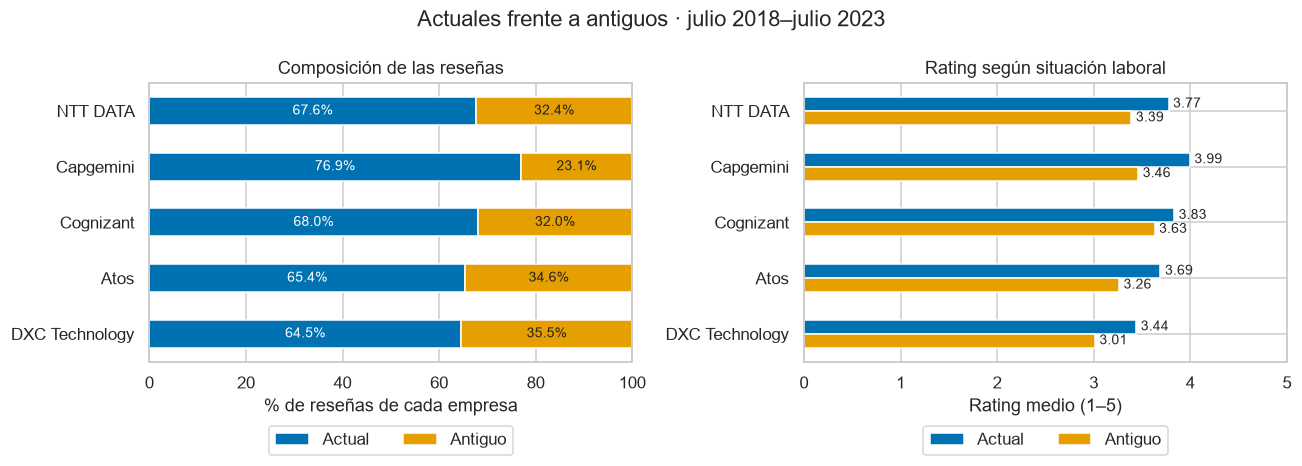

In [14]:
n_situacion = pd.crosstab(df_full["firm"], df_full["situacion"]).reindex(index=FIRMS, columns=["Actual", "Antiguo"])
situacion_pct = n_situacion.div(n_situacion.sum(axis=1), axis=0).mul(100)
rating_situacion = df_full.pivot_table(index="firm", columns="situacion", values="overall_rating", aggfunc="mean")
rating_situacion = rating_situacion.reindex(index=FIRMS, columns=["Actual", "Antiguo"])
display(pd.concat({"Reseñas": n_situacion, "Rating": rating_situacion.round(2)}, axis=1).rename(index=ETIQUETAS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
situacion_pct.rename(index=ETIQUETAS).plot.barh(stacked=True, color=["#0072B2", "#E69F00"], ax=axes[0])
for container, color in zip(axes[0].containers, ["white", "#222222"]):
    axes[0].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9, color=color)
rating_situacion.rename(index=ETIQUETAS).plot.barh(color=["#0072B2", "#E69F00"], ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3, fontsize=9)
axes[0].set(title="Composición de las reseñas", xlabel="% de reseñas de cada empresa", ylabel="", xlim=(0, 100))
axes[1].set(title="Rating según situación laboral", xlabel="Rating medio (1–5)", ylabel="", xlim=(0, 5))
for ax in axes:
    ax.invert_yaxis()
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
fig.suptitle("Actuales frente a antiguos · julio 2018–julio 2023")
plt.tight_layout()
plt.show()

**Lectura para RRHH.** El 67,6% de las reseñas de NTT DATA procede de actuales; su rating es 3,77 frente a 3,39 de antiguos. La diferencia no demuestra causas de salida: el análisis posterior deberá comparar los temas de los `cons`, teniendo en cuenta la autoselección de quienes publican.

### 3.5. Evolución: ¿cómo cambia el rating a lo largo del tiempo?

Medias anuales y recuentos por empresa. 2018 y 2023 cubren solo parte del año; no se comparan sus volúmenes con años completos.

firm,NTT DATA,Capgemini,Cognizant,Atos,DXC Technology
Año,,,,,
2018,194,742,1937,305,1011
2019,472,2680,5548,741,2836
2020,749,5091,8816,730,2516
2021,1634,10383,20573,1487,5423
2022,1055,6453,12459,1362,4120
2023,319,1466,1544,251,1572


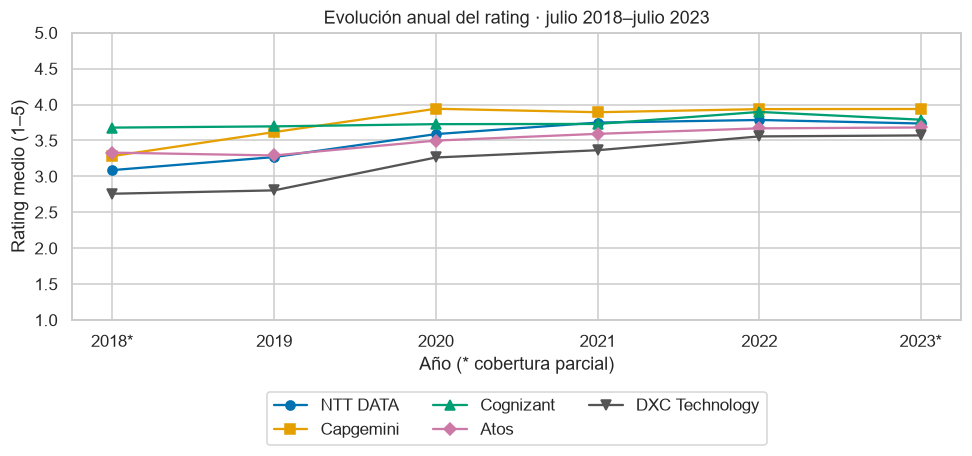

In [15]:
evolucion_rating = df_full.groupby(["anio", "firm"])["overall_rating"].mean().unstack().reindex(columns=FIRMS)
n_anual = pd.crosstab(df_full["anio"], df_full["firm"]).reindex(columns=FIRMS)
display(n_anual.rename(columns=ETIQUETAS).rename_axis("Año"))

fig, ax = plt.subplots(figsize=(9, 4.5))
for firm, marker in zip(FIRMS, ["o", "s", "^", "D", "v"]):
    ax.plot(evolucion_rating.index, evolucion_rating[firm], label=ETIQUETAS[firm], color=COLORES[firm], marker=marker)
ax.set(title="Evolución anual del rating · julio 2018–julio 2023", xlabel="Año (* cobertura parcial)", ylabel="Rating medio (1–5)", ylim=(1, 5))
ax.set_xticks([2018, 2019, 2020, 2021, 2022, 2023], ["2018*", "2019", "2020", "2021", "2022", "2023*"])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)
plt.tight_layout()
plt.show()

**Lectura para RRHH.** NTT DATA pasa de 3,27 en 2019 a 3,79 en 2022. El 3,74 de 2023 corresponde a un año parcial y no basta para concluir deterioro; conviene seguir la evolución con periodos equivalentes antes de cambiar prioridades.

## 4. Muestra equilibrada para NLP

Tomamos hasta 2.000 reseñas por empresa, sin reemplazo y con semilla fija, para limitar el coste y equilibrar la presencia de cada empresa. Conservamos los índices originales y los pares `pros`/`cons`; `df_full` sigue siendo la base del EDA.

In [16]:
df_nlp = pd.concat(
    [grupo.sample(n=min(MAX_REVIEWS_PER_COMPANY, len(grupo)), random_state=SEED)
     for _, grupo in df_full.groupby("firm", sort=True)]
).sort_index()

print(f"Muestra NLP: {len(df_nlp):,} reseñas")
df_nlp["firm"].value_counts().reindex(FIRMS).rename(index=ETIQUETAS).to_frame("Reseñas NLP")

Muestra NLP: 10,000 reseñas


,Reseñas NLP
firm,
NTT DATA,2000
Capgemini,2000
Cognizant,2000
Atos,2000
DXC Technology,2000


## 5. Análisis de sentimiento

Usamos [DistilBERT SST-2](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english), sugerido en el enunciado, para clasificar pros y cons por separado. Es un modelo ligero para inglés, ajustado con reseñas de cine, con dos etiquetas y sin categoría neutral. Aquí sirve como control de calidad; sus porcentajes no miden por sí solos la calidad del empleador.

In [17]:
from transformers import pipeline

SENTIMENT_MODEL = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
sentiment = pipeline("text-classification", model=SENTIMENT_MODEL, device=DEVICE)

C:\Users\forza\OneDrive - UMH\Máster\Deep Learning\Proyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:  68%|██████▊   | 71/104 [00:00<00:00, 703.33it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1000.48it/s]

Procesamos lotes de 16 textos en el dispositivo seleccionado y truncamos a 512 tokens para respetar el límite del modelo. Conservamos el texto completo y guardamos etiqueta y puntuación en `df_nlp`, con sus índices originales; la puntuación expresa confianza del modelo, no precisión comprobada.

In [18]:
for col in ["pros", "cons"]:
    textos = df_nlp[col].dropna()
    resultados = sentiment(textos.tolist(), batch_size=NLP_BATCH_SIZE,
                           truncation=True, max_length=512)
    df_nlp[[f"{col}_sentiment", f"{col}_score"]] = (
        pd.DataFrame(resultados, index=textos.index)
        .rename(columns={"label": f"{col}_sentiment", "score": f"{col}_score"})
    )
    print(f"{col}: {len(textos):,} textos clasificados")

pros: 10,000 textos clasificados


cons: 10,000 textos clasificados


Calculamos cada porcentaje sobre los textos clasificados de esa empresa y columna. La media de peers da el mismo peso a cada competidor; los gaps se expresan en puntos porcentuales (pp).

In [19]:
resumen_sentimiento = pd.DataFrame(index=FIRMS)
for col, etiqueta in [("pros", "POSITIVE"), ("cons", "NEGATIVE")]:
    etiquetas = df_nlp[f"{col}_sentiment"].dropna()
    resumen_sentimiento[f"{col} (n)"] = etiquetas.groupby(df_nlp["firm"]).count()
    resumen_sentimiento[f"{col} {etiqueta.lower()} (%)"] = (
        100 * etiquetas.eq(etiqueta).groupby(df_nlp["firm"]).mean()
    )

porcentajes_sentimiento = ["pros positive (%)", "cons negative (%)"]
comparacion_sentimiento = pd.DataFrame({
    "NTT DATA (%)": resumen_sentimiento.loc[TARGET, porcentajes_sentimiento],
    "Media peers (%)": resumen_sentimiento.loc[PEERS, porcentajes_sentimiento].mean()
})
comparacion_sentimiento["Gap (pp)"] = (
    comparacion_sentimiento["NTT DATA (%)"] - comparacion_sentimiento["Media peers (%)"]
)
comparacion_sentimiento.index = ["Pros positivos", "Cons negativos"]
display(resumen_sentimiento.rename(index=ETIQUETAS, columns={
    "pros (n)": "Pros (n)", "cons (n)": "Cons (n)",
    "pros positive (%)": "Pros positivos (%)", "cons negative (%)": "Cons negativos (%)"
}).round(2))
display(comparacion_sentimiento.round(2))

,Pros (n),Pros positivos (%),Cons (n),Cons negativos (%)
NTT DATA,2000,87.20,2000,83.10
Capgemini,2000,92.00,2000,78.65
Cognizant,2000,90.35,2000,79.55
Atos,2000,89.90,2000,84.75
DXC Technology,2000,87.00,2000,83.60


,NTT DATA (%),Media peers (%),Gap (pp)
Pros positivos,87.2,89.81,-2.61
Cons negativos,83.1,81.64,1.46


### Revisión manual de discordancias

Leemos cinco pros negativos y cinco cons positivos, elegidos al azar con semilla fija entre las cinco empresas. Una discordancia puede reflejar una respuesta válida, un texto ambiguo o un error del modelo; conservamos estos textos para el análisis posterior.

In [20]:
with pd.option_context("display.max_colwidth", None):
    for col, etiqueta in [("pros", "NEGATIVE"), ("cons", "POSITIVE")]:
        casos = df_nlp.loc[df_nlp[f"{col}_sentiment"].eq(etiqueta),
                           ["firm", col, f"{col}_score"]].sample(n=5, random_state=SEED)
        casos["firm"] = casos["firm"].replace(ETIQUETAS)
        print(f"{col}: clasificados como {etiqueta}")
        display(casos.round(3))

pros: clasificados como NEGATIVE


,firm,pros,pros_score
4478,Atos,Rolling through the revolving door,0.994
83570,DXC Technology,They can make better opportunities to the employees,0.984
21914,Capgemini,Not good during pandamic theese days,1.000
101896,NTT DATA,"Job security, if you can maintain client billing and have no growth aspirations",0.999
92992,DXC Technology,no micro-management (depending on the Team),0.994


cons: clasificados como POSITIVE


,firm,cons,cons_score
95093,DXC Technology,"No cons, only a good company",0.999
1237,Atos,"Frequent management change, restructuring and incompetent leaders working from decades",0.865
29865,Capgemini,Operational efficiency can be improved,0.999
57264,Cognizant,nothing as such. I had a great experience,0.994
101982,NTT DATA,Working hours are more when compared to other companies,0.916


### Interpretación

En NTT DATA, el **87,2 % de pros son positivos** y el **83,1 % de cons son negativos**: −2,61 y +1,46 pp frente a la media de peers. Predomina el sentimiento esperado. Solo 4 de los 20.000 textos superan los 512 tokens.

Los pros negativos incluyen críticas o ironía (NTT: seguridad condicionada a facturación y falta de crecimiento), pero también errores («no micro-management»). Los cons positivos incluyen ausencia de quejas («No cons»), sugerencias suaves y errores claros: mala dirección en Atos y jornadas largas en NTT. Una puntuación alta no garantiza acierto.

**Decisión:** conservamos todos los textos. Los porcentajes sirven como control de calidad; para priorizar acciones de RRHH necesitaremos identificar temas concretos, sin clasificar a los empleadores solo por sentimiento.

## 6. Topic modeling

[BERTopic](https://maartengr.github.io/BERTopic/index.html) agrupa textos por similitud semántica y describe cada grupo con palabras relevantes. Entrenamos **un modelo conjunto para pros y otro para cons**, con las cinco empresas; los identificadores de tema de ambos modelos son independientes. Conservamos las discordancias de sentimiento y respuestas como «No cons».

### 6.1. Embeddings

[MiniLM](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) representa cada texto en 384 dimensiones. Es un modelo compacto para inglés adecuado al equipo disponible; usa CUDA cuando existe y trunca a 256 tokens de forma predeterminada. Conservamos el texto completo y contamos los textos afectados.

In [21]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
MIN_TOPIC_SIZE = 100
MIN_SAMPLES = 10
embedding_model = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3412.10it/s]

In [22]:
textos_topics = {col: df_nlp[col].dropna() for col in ["pros", "cons"]}
embeddings_topics = {}
for col, textos in textos_topics.items():
    longitudes = embedding_model.tokenizer(textos.tolist(), truncation=False, padding=False,
                                          return_length=True, verbose=False)["length"]
    embeddings_topics[col] = embedding_model.encode(
        textos.tolist(), batch_size=NLP_BATCH_SIZE, normalize_embeddings=True,
        show_progress_bar=False
    )
    print(f"{col}: embeddings {embeddings_topics[col].shape}; "
          f"{sum(n > embedding_model.max_seq_length for n in longitudes)} textos truncados")

pros: embeddings (10000, 384); 3 textos truncados


cons: embeddings (10000, 384); 24 textos truncados


### 6.2. Agrupación conjunta

UMAP usa 15 vecinos, 5 dimensiones y distancia coseno para conservar proximidad semántica; `min_dist=0` facilita grupos compactos. La semilla fija favorece reproducibilidad. HDBSCAN exige al menos 100 textos por grupo (1 % de cada corpus) y `min_samples=10` para moderar el criterio de densidad y no descartar demasiados textos. Son valores iniciales, revisados mediante palabras y documentos.

Las stopwords inglesas se eliminan **solo de las descripciones**, no de los embeddings. Unigramas y bigramas capturan expresiones como «work life»; c-TF-IDF reduce el peso de palabras demasiado frecuentes. UMAP y HDBSCAN trabajan en CPU; no fijamos de antemano el número de temas.

In [23]:
modelos_topics = {}
for col, textos in textos_topics.items():
    modelo = BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                        metric="cosine", random_state=SEED, n_jobs=1),
        hdbscan_model=HDBSCAN(min_cluster_size=MIN_TOPIC_SIZE, min_samples=MIN_SAMPLES,
                              metric="euclidean", cluster_selection_method="eom",
                              prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words="english", ngram_range=(1, 2)),
        ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
        top_n_words=8, calculate_probabilities=False, verbose=False
    )
    topics, _ = modelo.fit_transform(textos.tolist(), embeddings=embeddings_topics[col])
    df_nlp[f"{col}_topic"] = pd.Series(topics, index=textos.index, dtype="Int64")
    modelos_topics[col] = modelo
    print(f"{col}: {df_nlp[f'{col}_topic'].loc[textos.index].nunique() - int(-1 in topics)} temas")

pros: 27 temas


cons: 26 temas


### 6.3. Palabras y documentos representativos

Mostramos los diez temas más frecuentes y un documento representativo de cada uno de los cinco principales. El peso usa todos los textos de cada corpus, incluidos los outliers. Los resúmenes completos quedan en `resumen_topics`; las palabras automáticas todavía no son categorías de negocio.

In [24]:
resumen_topics = {}
with pd.option_context("display.max_colwidth", None):
    for col, modelo in modelos_topics.items():
        tabla = modelo.get_topic_info().sort_values("Count", ascending=False).copy()
        tabla["Palabras"] = tabla["Representation"].str.join(", ")
        tabla["Peso (%)"] = 100 * tabla["Count"] / len(textos_topics[col])
        resumen_topics[col] = tabla
        temas = tabla.loc[tabla["Topic"].ge(0)]
        print(f"{col}: temas más frecuentes")
        display(temas[["Topic", "Count", "Peso (%)", "Palabras"]].head(10)
                .rename(columns={"Topic": "Tema", "Count": "Textos"}).round(2))
        ejemplos = temas.head(5)[["Topic", "Representative_Docs"]].copy()
        ejemplos["Representative_Docs"] = ejemplos["Representative_Docs"].str[0]
        display(ejemplos.rename(columns={"Topic": "Tema", "Representative_Docs": "Ejemplo"}))

pros: temas más frecuentes


,Tema,Textos,Peso (%),Palabras
1,0,854,8.54,"life balance, balance, work life, balance good, life, balance work, good work, balance great"
2,1,805,8.05,"salary, good salary, pay, benefits, salary good, time, good benefits, decent"
3,2,669,6.69,"culture, work culture, culture good, good culture, working culture, culture nice, culture great, diversity"
4,3,553,5.53,"good company, company work, company, great company, best company, company good, company start, nice company"
5,4,512,5.12,"flexible, timings, hours, flexibility, flexible work, flexible working, working hours, flexible timings"
6,5,346,3.46,"home, work home, home good, home work, working home, home option, option, home office"
7,6,292,2.92,"place work, place, good place, great place, work great, nice place, work good, best place"
8,7,260,2.60,"skills, learn, new skills, career growth, growth, learning, opportunities learn, opportunities"
9,8,257,2.57,"team, great team, good team, team good, team work, teams, nice team, environment team"
10,9,239,2.39,"management, leadership, managers, good management, management good, manager, environment management, supportive"


,Tema,Ejemplo
1,0,Work life balance is good
2,1,"Not many, except Pay on time and allowances if working on weekends. Easy to know and reach to your HRs if you are facing issues, and if you are lucky, u will get a good HR who will listen and solve your issue. But most of the time, they doesn't care, specially if you are in junior position. Good health insurance policy."
3,2,work culture is very good
4,3,It is good company to work with
5,4,Work life balance flexible timings good work


cons: temas más frecuentes


,Tema,Textos,Peso (%),Palabras
1,0,799,7.99,"culture, management, large, leadership, processes, changes, senior, managers"
2,1,683,6.83,"market, salary, compared, salary compared, low, pay, salaries, low salary"
3,2,662,6.62,"hike, hikes, hike hike, hikes hike, good hike, hikes hikes, hike bonus, hike promotion"
4,3,606,6.06,"cons, cons cons, cons good, don cons, good cons, cons till, cons far, till"
5,4,408,4.08,"work life, balance, life balance, life, balance work, pressure, work, work pressure"
6,5,340,3.40,"project, projects, technologies, technology, support, depends project, project project, old"
7,6,329,3.29,"say, mention, really really, say good, good good, think, comments, comments comments"
8,7,248,2.48,"think, till, moment, far, think moment, think think, experienced, experience think"
9,8,241,2.41,"good company, company good, company, company work, good place, place work, work good, place"
10,9,236,2.36,"salary hike, hike salary, hike, salary hikes, salary, hikes salary, hike low, hikes"


,Tema,Ejemplo
1,0,"Managers and Architects are straight-up racist, makes comments like ""Did you even went to college?"". Awful corporate culture. Got here to work on the cloud and then was forced to do service now when I'm not even qualified for that. We got promised a raise, but it came only once and Mexico members got 15% less than the colleagues from USA when it was supposed to be equal, and it came just once. I wish I could give 0 stars. Seriously, DO NOT WORK HERE."
2,1,Salary is less compared to market standards
3,2,"some teams have good upper management and some don't... also, hike is not that appropriate. i last worked in March 2022 and left DXC for personal reasons, but they haven't paid back my gratuity for completing 6 years of service. bad move, i will say. and worse than that, they don't even reply to emails. So, if I leave the company on my own accord, i am not eligible to be paid fairly for my hardwork all these years. WOW"
4,3,No Cons No Cons No Cons No Cons No Cons
5,4,Sometimes the work life balance


¿Qué temas concentran más textos? Comparamos el peso de los seis principales en cada corpus; los temas restantes y los outliers no aparecen en estas barras.

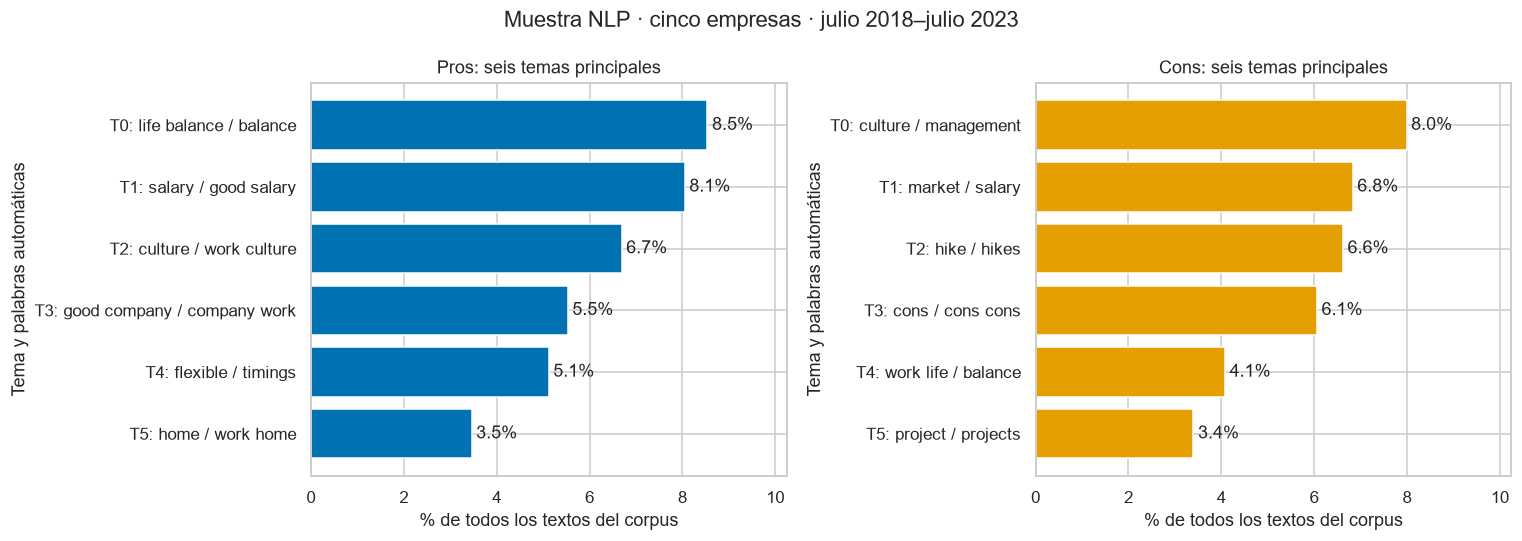

In [25]:
limite_x = 1.2 * max(tabla.loc[tabla["Topic"].ge(0), "Peso (%)"].max()
                     for tabla in resumen_topics.values())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color in zip(axes, ["pros", "cons"], ["#0072B2", "#E69F00"]):
    principales = resumen_topics[col].loc[lambda tabla: tabla["Topic"].ge(0)].head(6)
    nombres = [f"T{fila.Topic}: " + " / ".join(fila.Representation[:2])
               for fila in principales.itertuples()]
    ax.barh(nombres, principales["Peso (%)"], color=color)
    ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
    ax.invert_yaxis()
    ax.set(title=f"{col.capitalize()}: seis temas principales", xlabel="% de todos los textos del corpus",
           ylabel="Tema y palabras automáticas", xlim=(0, limite_x))
fig.suptitle("Muestra NLP · cinco empresas · julio 2018–julio 2023")
plt.tight_layout()
plt.show()

### 6.4. Textos sin tema asignado

HDBSCAN marca con `−1` los textos que no encajan en sus grupos. Medimos esa cobertura por empresa y leemos tres ejemplos al azar de cada corpus, sin confundir un texto ausente con un outlier.

In [26]:
cobertura_topics = pd.DataFrame(index=["pros", "cons"])
outliers_empresa = pd.DataFrame(index=FIRMS)
for col in ["pros", "cons"]:
    asignaciones = df_nlp[f"{col}_topic"].dropna()
    cobertura_topics.loc[col, "Textos"] = len(asignaciones)
    cobertura_topics.loc[col, "Temas"] = asignaciones.loc[asignaciones.ge(0)].nunique()
    cobertura_topics.loc[col, "Sin tema (n)"] = asignaciones.eq(-1).sum()
    cobertura_topics.loc[col, "Sin tema (%)"] = 100 * asignaciones.eq(-1).mean()
    outliers_empresa[f"{col} sin tema (%)"] = (
        100 * asignaciones.eq(-1).groupby(df_nlp["firm"]).mean()
    )
display(cobertura_topics.round(2))
display(outliers_empresa.rename(index=ETIQUETAS).round(2))
with pd.option_context("display.max_colwidth", None):
    for col in ["pros", "cons"]:
        sin_tema = df_nlp.loc[df_nlp[f"{col}_topic"].eq(-1), ["firm", col]]
        print(f"{col}: ejemplos sin tema")
        display(sin_tema.sample(n=min(3, len(sin_tema)), random_state=SEED)
                .replace({"firm": ETIQUETAS}))

,Textos,Temas,Sin tema (n),Sin tema (%)
pros,10000.0,27.0,2632.0,26.32
cons,10000.0,26.0,2807.0,28.07


,pros sin tema (%),cons sin tema (%)
NTT DATA,27.8,25.95
Capgemini,26.9,28.35
Cognizant,28.5,28.75
Atos,26.0,27.95
DXC Technology,22.4,29.35


pros: ejemplos sin tema


,firm,pros
2042,Atos,Atos benefits are salary and friendly working environment.
2970,Atos,"Since the first contact with talent acquisition all the information regarding the open position were provided, the on boarding was smooth and the experts there have a lot of experience."
18089,Capgemini,"Nice working culture, beautiful and clean campus, gifts and recognitions, work-life balance, Diversity and inclusion, healthy formality-fun balance"


cons: ejemplos sin tema


,firm,cons
100933,NTT DATA,Secure job No any leave issue
103165,NTT DATA,Hard to get a perm role
71309,Cognizant,NA NA NA NA na


### Interpretación y tratamiento de outliers

Obtenemos **27 temas en pros y 26 en cons**. Los ejemplos respaldan grupos sobre conciliación, salario, cultura y flexibilidad; también aparecen elogios genéricos y varios grupos de subidas salariales. En cons, el tema 3 contiene «No cons»: no representa una queja. Son patrones del conjunto de las cinco empresas, todavía no fortalezas o problemas específicos de NTT DATA.

Quedan **26,32 % de pros y 28,07 % de cons sin tema**; en NTT DATA, 27,80 % y 25,95 %. Los ejemplos mezclan textos con varios asuntos, experiencias concretas (dificultad de conseguir un puesto permanente) y respuestas poco informativas («NA»).

**Decisión:** conservamos `−1` como «sin tema», sin eliminar ni forzar asignaciones. Los porcentajes mantienen todos los textos como denominador y mostraremos la cobertura al comparar empresas; una parte relevante queda sin caracterizar. Cada texto recibe un único tema, aunque pueda mencionar varios asuntos. La conversión a categorías de negocio requerirá revisión manual.

## 7. Categorías de negocio

Revisamos las palabras, tres documentos representativos y tres textos al azar de cada tema del apartado 6; ampliamos la lectura en grupos ambiguos. Definimos categorías comunes a pros y cons según el asunto dominante, sin usar la empresa ni su rating. Es una revisión muestral, no una comprobación de cada texto.

Las equivalencias son editables y corresponden a estos modelos y parámetros. Si cambia el entrenamiento, deben revisarse: un mismo número de tema no significa lo mismo en pros y cons.

In [27]:
equivalencias_topics = pd.DataFrame([
    ("Compensación y beneficios", [1], [1, 2, 9, 12, 14, 17, 21], "Negocio",
     "Salario, subidas, bonus, seguros y efectos económicos de las evaluaciones."),
    ("Conciliación y flexibilidad", [0, 4, 5, 15, 22], [4, 10, 25], "Negocio",
     "Equilibrio personal, horarios, turnos, presión y trabajo remoto."),
    ("Cultura y relaciones laborales", [2, 8, 11, 13, 21], [24], "Negocio",
     "Ambiente, compañeros, colaboración y política interna."),
    ("Dirección y gestión de personas", [9], [0, 19], "Negocio",
     "Liderazgo, organización, comunicación y atención de RRHH."),
    ("Formación y desarrollo profesional", [7, 10, 16], [16, 18, 20, 23], "Negocio",
     "Aprendizaje, incorporación, movilidad y ascensos; no subidas salariales."),
    ("Proyectos, clientes y tecnología", [12, 14], [5, 22], "Negocio",
     "Asignación de proyectos, clientes, contenido del trabajo y tecnologías."),
    ("Estabilidad laboral", [23], [], "Negocio", "Seguridad y continuidad del empleo."),
    ("Valoración general", [3, 6, 17, 19], [8, 15], "Control",
     "Juicios generales, positivos o negativos, sin un asunto consistente."),
    ("Varios asuntos", [18, 20, 24, 26], [11, 13], "Control",
     "Grupos con varios asuntos sin predominio claro, incluidos nombres de empresas."),
    ("Sin quejas declaradas", [], [3, 6, 7], "Control",
     "Predominan respuestas como 'No cons' o 'Nothing I can think of'."),
    ("Sin contenido concreto", [25], [], "Control", "Respuestas como 'NA' o 'Nothing specific'."),
    ("Sin tema", [-1], [-1], "Control", "Textos no agrupados por HDBSCAN.")
], columns=["Categoría", "pros", "cons", "Tipo", "Criterio"]).set_index("Categoría")

with pd.option_context("display.max_colwidth", None):
    display(equivalencias_topics.rename(columns={"pros": "Topics pros", "cons": "Topics cons"}))

,Topics pros,Topics cons,Tipo,Criterio
Categoría,,,,
Compensación y beneficios,[1],"[1, 2, 9, 12, 14, 17, 21]",Negocio,"Salario, subidas, bonus, seguros y efectos económicos de las evaluaciones."
Conciliación y flexibilidad,"[0, 4, 5, 15, 22]","[4, 10, 25]",Negocio,"Equilibrio personal, horarios, turnos, presión y trabajo remoto."
Cultura y relaciones laborales,"[2, 8, 11, 13, 21]",[24],Negocio,"Ambiente, compañeros, colaboración y política interna."
Dirección y gestión de personas,[9],"[0, 19]",Negocio,"Liderazgo, organización, comunicación y atención de RRHH."
Formación y desarrollo profesional,"[7, 10, 16]","[16, 18, 20, 23]",Negocio,"Aprendizaje, incorporación, movilidad y ascensos; no subidas salariales."
"Proyectos, clientes y tecnología","[12, 14]","[5, 22]",Negocio,"Asignación de proyectos, clientes, contenido del trabajo y tecnologías."
Estabilidad laboral,[23],[],Negocio,Seguridad y continuidad del empleo.
Valoración general,"[3, 6, 17, 19]","[8, 15]",Control,"Juicios generales, positivos o negativos, sin un asunto consistente."
Varios asuntos,"[18, 20, 24, 26]","[11, 13]",Control,"Grupos con varios asuntos sin predominio claro, incluidos nombres de empresas."


Aplicamos una categoría por texto, conservando sus temas, índices y sentimiento originales. Las filas de control permanecen en `df_nlp` y en los denominadores; no son prioridades de RRHH. Una lista vacía indica que no encontramos un grupo específico, no ausencia de ese asunto en las reseñas.

In [28]:
MAPAS_CATEGORIAS = {
    col: {tema: categoria for categoria, temas in equivalencias_topics[col].items() for tema in temas}
    for col in ["pros", "cons"]
}
CATEGORIAS_NEGOCIO = equivalencias_topics.index[equivalencias_topics["Tipo"].eq("Negocio")].tolist()

for col in ["pros", "cons"]:
    df_nlp[f"{col}_categoria"] = df_nlp[f"{col}_topic"].map(MAPAS_CATEGORIAS[col]).astype("string")

cobertura_categorias = pd.DataFrame({
    col: df_nlp[f"{col}_categoria"].map(equivalencias_topics["Tipo"])
         .value_counts(normalize=True).mul(100)
    for col in ["pros", "cons"]
}).reindex(["Negocio", "Control"])
display(cobertura_categorias.rename(columns={"pros": "Pros (%)", "cons": "Cons (%)"}).round(2))

,Pros (%),Cons (%)
Negocio,56.57,51.67
Control,43.43,48.33


### Revisión de decisiones

Reunimos salario, subidas, bonus y evaluaciones con efectos económicos en compensación; los ascensos van a desarrollo profesional. Los grupos que combinan cultura y conciliación, o salario y dirección, quedan en «Varios asuntos». Las respuestas genéricas y «No cons» se separan de los asuntos concretos. Mostramos ejemplos de estas decisiones; el detalle de todos los temas queda en `revision_categorias`.

In [29]:
revision_categorias = pd.concat([
    tabla.assign(Campo=col, Categoría=tabla["Topic"].map(MAPAS_CATEGORIAS[col]),
                 Ejemplo=tabla["Representative_Docs"].str[0])
         [["Campo", "Topic", "Categoría", "Palabras", "Ejemplo"]]
    for col, tabla in resumen_topics.items()
], ignore_index=True)
casos_revision = pd.MultiIndex.from_tuples(
    [("pros", 18), ("pros", 25), ("cons", 3), ("cons", 13), ("cons", 21)],
    names=["Campo", "Topic"]
)
with pd.option_context("display.max_colwidth", None):
    display(revision_categorias.set_index(["Campo", "Topic"]).loc[casos_revision]
            .rename_axis(index={"Topic": "Tema"}))

Categoría  \
Campo Tema                              
pros  18               Varios asuntos   
      25       Sin contenido concreto   
cons  3         Sin quejas declaradas   
      13               Varios asuntos   
      21    Compensación y beneficios   

                                                                                                                                 Palabras  \
Campo Tema                                                                                                                                  
pros  18                                     culture work, balance culture, culture, work culture, life balance, balance, work life, life   
      25                                                                  na, na na, think, say, think think, positive, comments, mention   
cons  3                                                        cons, cons cons, cons good, don cons, good cons, cons till, cons far, till   
      13                                                poor, poor management, bad management, low, low pay, low salary, bad, salary poor   
      21    appraisal, appraisals, appraisal process, appraisal cycle, appraisal good, good appraisal, appraisal appraisal, low appraisal   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Ejemplo  
Campo Tema                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
pros  18                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               Good work culture, work life balance is good.  
      25                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              na na na na na  
cons  3                                                                                                                                                                                                                                                                                                                                                                                                                             

### Interpretación

La revisión define **siete categorías de negocio**, que recogen el **56,57 % de los pros y el 51,67 % de los cons**. El resto permanece en grupos de control: valoración general, varios asuntos, ausencia de quejas, contenido poco concreto y textos sin tema. Esta cobertura no mide precisión.

Las categorías describen el asunto, sin garantizar el sentimiento de cada texto. Los temas mixtos y las diferencias de cobertura limitan la comparación; una categoría sin un grupo específico puede aparecer en otros temas o en outliers. Conservamos las equivalencias y los ejemplos para revisar las decisiones antes de establecer prioridades de RRHH.

## 8. Comparación de NTT DATA con peers

### 8.1. Porcentajes y cobertura

Usamos `df_nlp`: 2.000 reseñas por empresa. Cada porcentaje usa todos los textos disponibles de esa empresa y campo, incluidos los grupos de control; no renormalizamos solo las categorías de negocio. La tabla muestra cuánto contenido queda en esas siete categorías; el resto permanece en control.

In [30]:
n_textos_categoria = df_nlp.groupby("firm")[["pros", "cons"]].count().reindex(FIRMS)
recuentos_categorias = {}
porcentajes_categorias = {}
for col in ["pros", "cons"]:
    recuentos_categorias[col] = pd.crosstab(df_nlp["firm"], df_nlp[f"{col}_categoria"]).reindex(
        index=FIRMS, columns=equivalencias_topics.index, fill_value=0
    )
    porcentajes_categorias[col] = recuentos_categorias[col].div(n_textos_categoria[col], axis=0).mul(100)

cobertura_empresas = n_textos_categoria.rename(columns={"pros": "Pros (n)", "cons": "Cons (n)"}).copy()
for col in ["pros", "cons"]:
    cobertura_empresas[f"{col.capitalize()} negocio (%)"] = porcentajes_categorias[col][CATEGORIAS_NEGOCIO].sum(axis=1)
display(cobertura_empresas.rename(index=ETIQUETAS).round(2))

,Pros (n),Cons (n),Pros negocio (%),Cons negocio (%)
firm,,,,
NTT DATA,2000,2000,57.70,55.55
Capgemini,2000,2000,53.80,50.45
Cognizant,2000,2000,54.35,52.10
Atos,2000,2000,58.50,49.50
DXC Technology,2000,2000,58.50,50.75


### 8.2. Balance y gap por categoría

**Balance = % pros − % cons. Gap = balance NTT DATA − media del balance de los cuatro peers**, con igual peso por empresa. Ambos se expresan en puntos porcentuales (pp): un gap negativo indica menor balance relativo. Usamos los campos originales sin filtrar por sentimiento; el balance no es una medida de satisfacción ni de gravedad.

In [31]:
balance_categorias = porcentajes_categorias["pros"][CATEGORIAS_NEGOCIO] - porcentajes_categorias["cons"][CATEGORIAS_NEGOCIO]
comparacion_categorias = pd.DataFrame({
    "Pros NTT (%)": porcentajes_categorias["pros"].loc[TARGET, CATEGORIAS_NEGOCIO],
    "Pros peers (%)": porcentajes_categorias["pros"].loc[PEERS, CATEGORIAS_NEGOCIO].mean(),
    "Cons NTT (%)": porcentajes_categorias["cons"].loc[TARGET, CATEGORIAS_NEGOCIO],
    "Cons peers (%)": porcentajes_categorias["cons"].loc[PEERS, CATEGORIAS_NEGOCIO].mean(),
    "Balance NTT (pp)": balance_categorias.loc[TARGET],
    "Balance peers (pp)": balance_categorias.loc[PEERS].mean()
})
comparacion_categorias["Gap (pp)"] = comparacion_categorias["Balance NTT (pp)"] - comparacion_categorias["Balance peers (pp)"]
display(comparacion_categorias.sort_values("Gap (pp)").round(2))

,Pros NTT (%),Pros peers (%),Cons NTT (%),Cons peers (%),Balance NTT (pp),Balance peers (pp),Gap (pp)
Categoría,,,,,,,
Formación y desarrollo profesional,5.0,6.96,6.50,5.89,-1.50,1.07,-2.57
Compensación y beneficios,10.0,7.56,26.55,21.94,-16.55,-14.38,-2.18
Cultura y relaciones laborales,13.2,14.92,0.65,1.10,12.55,13.82,-1.28
"Proyectos, clientes y tecnología",4.4,3.95,5.50,4.70,-1.10,-0.75,-0.35
Estabilidad laboral,1.6,0.99,0.00,0.00,1.60,0.99,0.61
Conciliación y flexibilidad,21.0,19.54,8.05,7.28,12.95,12.26,0.69
Dirección y gestión de personas,2.5,2.36,8.30,9.80,-5.80,-7.44,1.64


### 8.3. ¿Dónde difiere más NTT DATA del balance de peers?

Ordenamos las categorías por gap. Los porcentajes son relativos y las categorías tienen distinta cobertura entre empresas; el gráfico muestra diferencias descriptivas, sin establecer significación estadística ni prioridades definitivas.

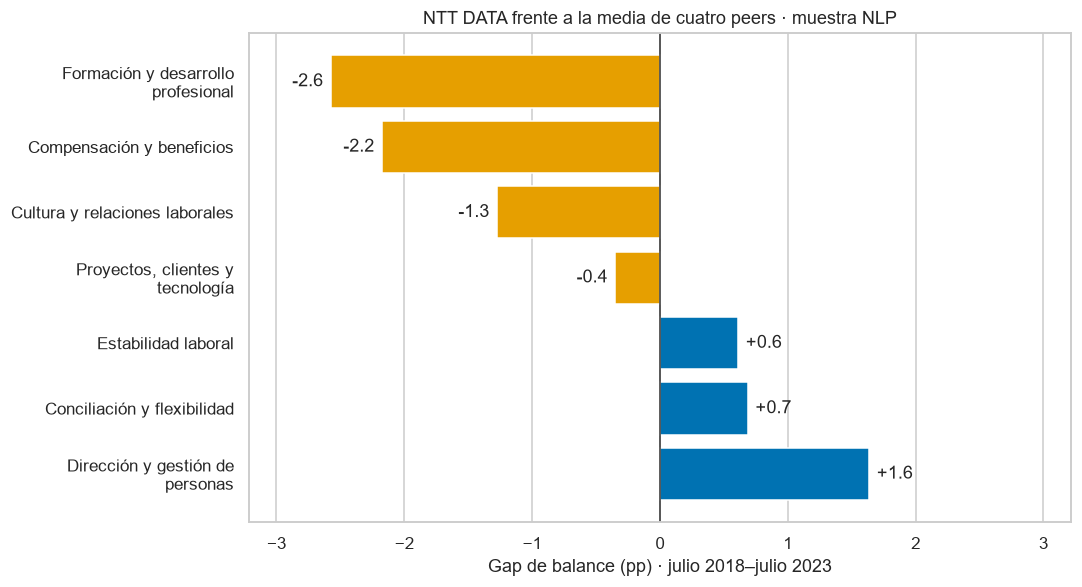

In [32]:
from textwrap import fill

gaps_categorias = comparacion_categorias["Gap (pp)"].sort_values()
colores_gap = np.where(gaps_categorias.lt(0), "#E69F00", "#0072B2")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh([fill(categoria, 30) for categoria in gaps_categorias.index], gaps_categorias, color=colores_gap)
ax.bar_label(ax.containers[0], fmt="%+.1f", padding=5)
ax.axvline(0, color="#333333", linewidth=1)
limite_gap = 1.25 * gaps_categorias.abs().max()
ax.set(title="NTT DATA frente a la media de cuatro peers · muestra NLP", xlabel="Gap de balance (pp) · julio 2018–julio 2023",
       ylabel="", xlim=(-limite_gap, limite_gap))
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Interpretación de la comparación

- **Compensación:** concentra el 26,55 % de cons de NTT DATA frente al 21,94 % de peers; su gap de balance es −2,18 pp.
- **Formación y desarrollo:** presenta el gap más desfavorable (−2,57 pp), sobre todo por menor presencia en pros: 5,00 % frente a 6,96 %.
- **Conciliación** tiene balance positivo (12,95 pp) y gap de +0,69 pp. **Dirección** tiene balance negativo (−5,80 pp), aunque es menos desfavorable que en peers: gap de +1,64 pp.

**Límite:** la cobertura de negocio en cons es 55,55 % en NTT DATA y 50,70 % de media en peers. El 0 % de cons de estabilidad refleja que no identificamos un grupo específico. Compensación y desarrollo son candidatos a contrastar con rating y recomendación antes de priorizar acciones; estos resultados no prueban diferencias en toda la plantilla.

## 9. Contraste con rating y recomendación

### 9.1. Categoría frente al resto de NTT DATA

Usamos `df_nlp`, donde están las categorías. Para cada categoría de cons comparamos sus reseñas con el resto de NTT DATA con cons disponible, incluidos los grupos de control. «Resto» significa sin esa asignación, no ausencia real del asunto. El rating usa la escala 1–5; el porcentaje de «Sí» excluye «Sin opinión» y mostramos cuántas personas opinan. Son asociaciones descriptivas, sin filtrar por sentimiento ni demostrar causalidad.

In [33]:
base_contraste = df_nlp.loc[df_nlp["firm"].eq(TARGET) & df_nlp["cons"].notna()].copy()
base_contraste["si_con_opinion"] = base_contraste["recomienda"].map({"Sí": 1, "No": 0})
filas_contraste = []
for categoria in CATEGORIAS_NEGOCIO:
    asignada = base_contraste["cons_categoria"].eq(categoria).fillna(False)
    casos = base_contraste.loc[asignada]
    resto = base_contraste.loc[~asignada]
    filas_contraste.append({
        "Categoría": categoria, "Cons (n)": len(casos), "Opinan (n)": casos["si_con_opinion"].count(),
        "Rating": casos["overall_rating"].mean(), "Rating resto": resto["overall_rating"].mean(),
        "Δ rating": casos["overall_rating"].mean() - resto["overall_rating"].mean(),
        "Sí (%)": 100 * casos["si_con_opinion"].mean(), "Sí resto (%)": 100 * resto["si_con_opinion"].mean(),
        "Δ Sí (pp)": 100 * (casos["si_con_opinion"].mean() - resto["si_con_opinion"].mean())
    })
contraste_estructurado = pd.DataFrame(filas_contraste).set_index("Categoría")
print(f"Base NTT DATA: {len(base_contraste):,} reseñas; {base_contraste['si_con_opinion'].count():,} con opinión.")
tabla_contraste = contraste_estructurado.round(2)
tabla_contraste["Δ rating"] = contraste_estructurado["Δ rating"].round(3)
display(tabla_contraste)

Base NTT DATA: 2,000 reseñas; 1,356 con opinión.


,Cons (n),Opinan (n),Rating,Rating resto,Δ rating,Sí (%),Sí resto (%),Δ Sí (pp)
Categoría,,,,,,,,
Compensación y beneficios,531,353,3.62,3.67,-0.046,72.80,68.99,3.81
Conciliación y flexibilidad,161,106,3.80,3.64,0.159,81.13,69.04,12.09
Cultura y relaciones laborales,13,9,3.15,3.66,-0.505,33.33,70.23,-36.90
Dirección y gestión de personas,166,120,3.46,3.67,-0.216,62.50,70.71,-8.21
Formación y desarrollo profesional,130,88,3.65,3.66,-0.002,69.32,70.03,-0.71
"Proyectos, clientes y tecnología",110,76,3.61,3.66,-0.049,60.53,70.55,-10.02
Estabilidad laboral,0,0,NaN,3.66,NaN,NaN,69.99,NaN


### 9.2. ¿Acompañan estas categorías peores valoraciones?

Una diferencia negativa indica menor rating o recomendación que el resto de reseñas. Los dos paneles usan unidades distintas. Estabilidad no aparece: no hay cons asignados a ella y sus medias quedan ausentes, no en cero. Los recuentos pequeños requieren cautela; no calculamos significación estadística.

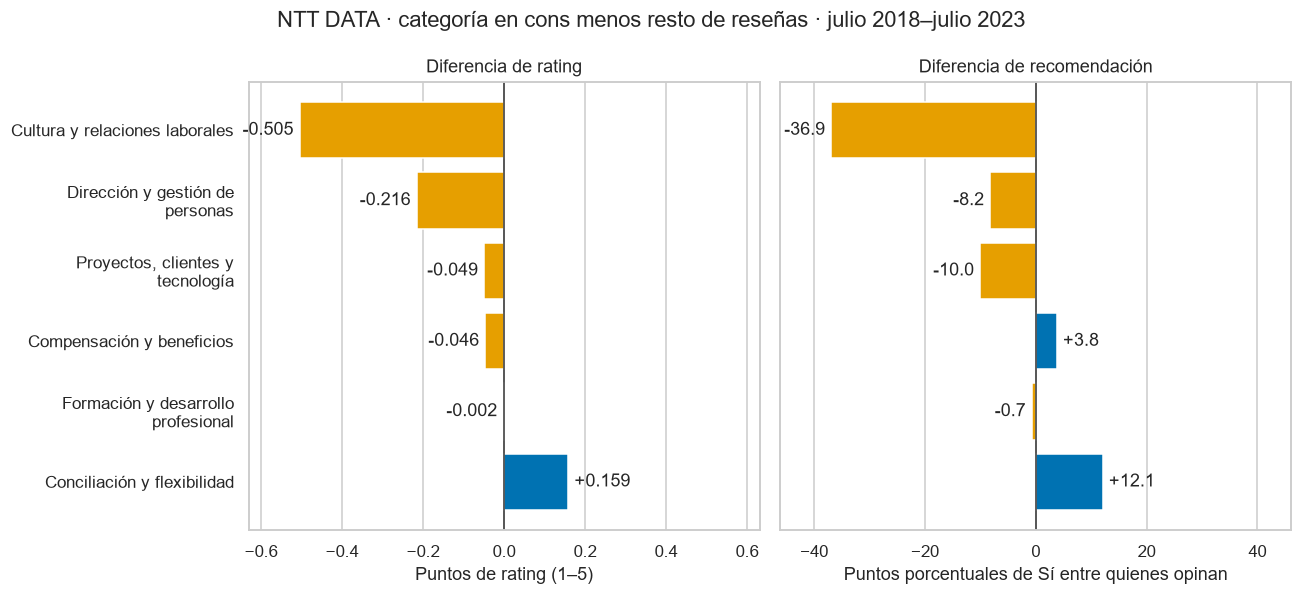

In [34]:
datos_contraste = contraste_estructurado.dropna(subset=["Δ rating", "Δ Sí (pp)"]).sort_values("Δ rating")
nombres_contraste = [fill(categoria, 30) for categoria in datos_contraste.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
for ax, columna, titulo, unidad, formato in zip(
    axes, ["Δ rating", "Δ Sí (pp)"], ["Diferencia de rating", "Diferencia de recomendación"],
    ["Puntos de rating (1–5)", "Puntos porcentuales de Sí entre quienes opinan"], ["%+.3f", "%+.1f"]
):
    valores = datos_contraste[columna]
    ax.barh(nombres_contraste, valores, color=np.where(valores.lt(0), "#E69F00", "#0072B2"))
    ax.bar_label(ax.containers[0], fmt=formato, padding=4)
    ax.axvline(0, color="#333333", linewidth=1)
    limite = 1.25 * valores.abs().max()
    ax.set(title=titulo, xlabel=unidad, ylabel="", xlim=(-limite, limite))
    ax.grid(axis="y", visible=False)
axes[0].invert_yaxis()
fig.suptitle("NTT DATA · categoría en cons menos resto de reseñas · julio 2018–julio 2023")
plt.tight_layout()
plt.show()

### Interpretación del contraste

- **Dirección:** sus 166 reseñas tienen menor rating (3,46 frente a 3,67) y recomendación (62,50 % frente a 70,71 %). Ambos indicadores acompañan una valoración más desfavorable, aunque el balance frente a peers del apartado 8 era mejor.
- **Compensación:** rating próximo al resto (3,62 frente a 3,67) y mayor recomendación (72,80 % frente a 68,99 %). **Desarrollo** presenta valores casi iguales: rating 3,65 frente a 3,66 y recomendación 69,32 % frente a 70,03 %. El contraste no refuerza de forma consistente los gaps desfavorables del apartado 8.
- **Cultura:** muestra diferencias mayores, pero solo dispone de 13 reseñas y 9 opiniones. **Proyectos** tiene menor recomendación (60,53 % frente a 70,55 %), con rating similar.

Conciliación obtiene valores superiores al resto: una queja concreta puede convivir con una valoración global positiva. Estos resultados matizan los candidatos a priorizar; no validan la precisión de las categorías ni prueban causas, y pueden reflejar diferencias de perfil, país o intensidad de las quejas.

## 10. Empleados actuales y antiguos

### 10.1. Tamaño y cobertura de cada grupo

Usamos los cons de `df_nlp` con situación identificada. Cada porcentaje usa todos los cons disponibles de esa empresa y situación, incluidos los grupos de control. La muestra está equilibrada por empresa, no por situación; mostramos recuentos y cobertura antes de comparar. El porcentaje restante queda en control; «Sin tema» es una parte de ese control.

In [35]:
base_situacion = df_nlp.loc[df_nlp["cons"].notna() & df_nlp["situacion"].isin(["Actual", "Antiguo"])]
grupos_situacion = pd.MultiIndex.from_product([FIRMS, ["Actual", "Antiguo"]], names=["firm", "situacion"])
n_cons_situacion = base_situacion.groupby(["firm", "situacion"])["cons"].count().reindex(grupos_situacion, fill_value=0)
recuentos_situacion = pd.crosstab(
    [base_situacion["firm"], base_situacion["situacion"]], base_situacion["cons_categoria"]
).reindex(index=grupos_situacion, columns=equivalencias_topics.index, fill_value=0)
porcentajes_situacion = recuentos_situacion.div(n_cons_situacion, axis=0).mul(100)
cobertura_situacion = pd.DataFrame({
    "Cons (n)": n_cons_situacion,
    "Negocio (%)": porcentajes_situacion[CATEGORIAS_NEGOCIO].sum(axis=1, min_count=1),
    "Sin tema (%)": porcentajes_situacion["Sin tema"]
})
display(cobertura_situacion.unstack("situacion").rename(index=ETIQUETAS).round(2))

Cons (n)         Negocio (%)         Sin tema (%)        
situacion        Actual Antiguo      Actual Antiguo       Actual Antiguo
firm                                                                    
Atos               1279     721       49.73   49.10        25.80   31.76
Capgemini          1513     487       49.04   54.83        28.35   28.34
Cognizant          1371     629       51.79   52.78        28.37   29.57
DXC Technology     1290     710       51.86   48.73        28.06   31.69
NTT DATA           1366     634       56.30   53.94        24.52   29.02

### 10.2. Temas de antiguos frente a actuales y peers

**Δ situación = % antiguos NTT DATA − % actuales NTT DATA. Δ peers = % antiguos NTT DATA − media de % antiguos de los cuatro peers**, con igual peso por empresa. Son diferencias de presencia en cons, no gaps de balance. Un valor positivo no demuestra mayor gravedad ni que el asunto causara la salida; los antiguos pueden publicar por razones distintas.

In [36]:
comparacion_situacion = pd.DataFrame({
    "Actual (n)": recuentos_situacion.loc[(TARGET, "Actual"), CATEGORIAS_NEGOCIO],
    "Actual (%)": porcentajes_situacion.loc[(TARGET, "Actual"), CATEGORIAS_NEGOCIO],
    "Antiguo (n)": recuentos_situacion.loc[(TARGET, "Antiguo"), CATEGORIAS_NEGOCIO],
    "Antiguo (%)": porcentajes_situacion.loc[(TARGET, "Antiguo"), CATEGORIAS_NEGOCIO],
    "Peers antiguo (%)": porcentajes_situacion.xs("Antiguo", level="situacion").loc[PEERS, CATEGORIAS_NEGOCIO].mean()
})
comparacion_situacion["Δ situación (pp)"] = comparacion_situacion["Antiguo (%)"] - comparacion_situacion["Actual (%)"]
comparacion_situacion["Δ peers (pp)"] = comparacion_situacion["Antiguo (%)"] - comparacion_situacion["Peers antiguo (%)"]
display(comparacion_situacion.round(2))

,Actual (n),Actual (%),Antiguo (n),Antiguo (%),Peers antiguo (%),Δ situación (pp),Δ peers (pp)
Categoría,,,,,,,
Compensación y beneficios,378,27.67,153,24.13,20.17,-3.54,3.97
Conciliación y flexibilidad,111,8.13,50,7.89,7.45,-0.24,0.44
Cultura y relaciones laborales,7,0.51,6,0.95,1.48,0.43,-0.53
Dirección y gestión de personas,102,7.47,64,10.09,10.86,2.63,-0.76
Formación y desarrollo profesional,92,6.73,38,5.99,5.99,-0.74,0.00
"Proyectos, clientes y tecnología",79,5.78,31,4.89,5.42,-0.89,-0.53
Estabilidad laboral,0,0.00,0,0.00,0.00,0.00,0.00


### 10.3. ¿Qué asuntos destacan en los cons de antiguos?

Comparamos primero situaciones dentro de NTT DATA y después antiguos entre empresas, con la misma escala. Los porcentajes son relativos y cada texto recibe una sola categoría. El cero de estabilidad refleja que no encontramos un grupo específico en cons, no ausencia de ese problema.

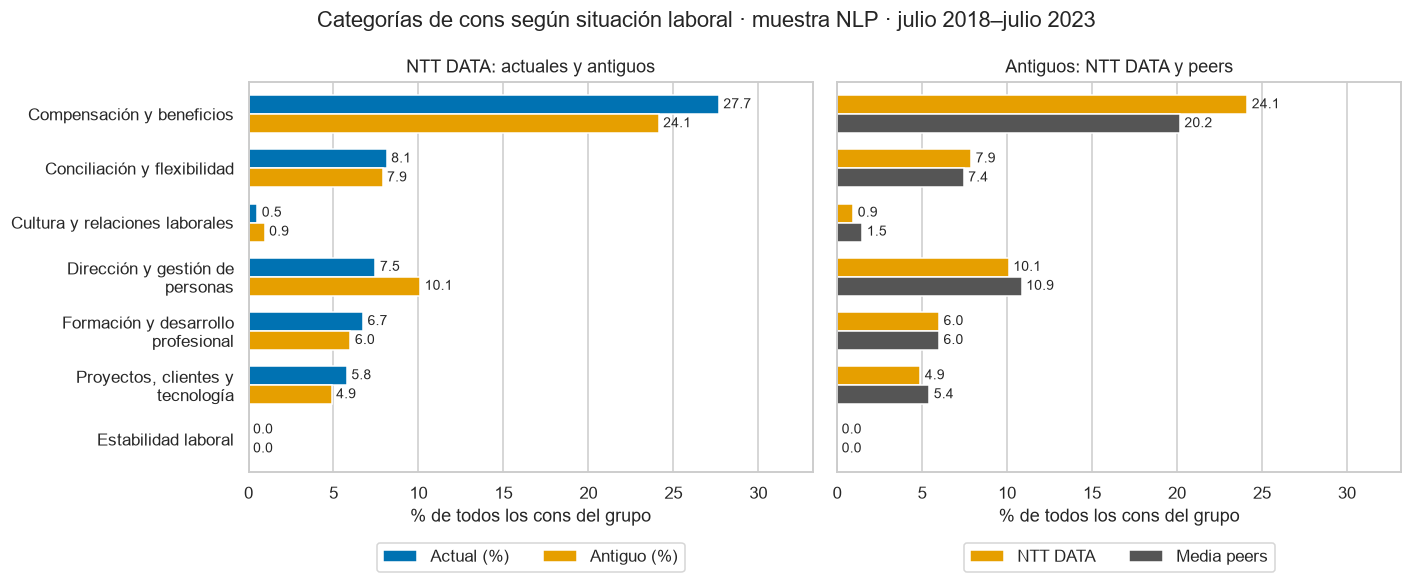

In [37]:
comparacion_antiguos = comparacion_situacion[["Antiguo (%)", "Peers antiguo (%)"]].rename(
    columns={"Antiguo (%)": "NTT DATA", "Peers antiguo (%)": "Media peers"}
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
limite_situacion = 1.2 * comparacion_situacion[["Actual (%)", "Antiguo (%)", "Peers antiguo (%)"]].max().max()
for ax, datos, colores, titulo in zip(
    axes, [comparacion_situacion[["Actual (%)", "Antiguo (%)"]], comparacion_antiguos],
    [["#0072B2", "#E69F00"], ["#E69F00", "#555555"]], ["NTT DATA: actuales y antiguos", "Antiguos: NTT DATA y peers"]
):
    datos.rename(index=lambda categoria: fill(categoria, 30)).plot.barh(ax=ax, color=colores, width=0.7)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
    ax.set(title=titulo, xlabel="% de todos los cons del grupo", ylabel="", xlim=(0, limite_situacion))
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
axes[0].invert_yaxis()
fig.suptitle("Categorías de cons según situación laboral · muestra NLP · julio 2018–julio 2023")
plt.tight_layout()
plt.show()

### Interpretación para RRHH

- **Compensación:** aparece en 153 de los 634 cons de antiguos de NTT DATA (24,13 %), frente al 20,17 % de media en antiguos de peers: +3,97 pp. Entre actuales de NTT DATA pesa más (27,67 %); no es un asunto exclusivo de quienes se marcharon.
- **Dirección:** aumenta del 7,47 % entre actuales al 10,09 % entre antiguos (+2,63 pp), pero queda por debajo del 10,86 % de antiguos de peers. Es un patrón interno a explorar, sin desventaja descriptiva frente a ese grupo de competidores.
- **Desarrollo:** pesa un 5,99 % entre antiguos de NTT DATA y aproximadamente lo mismo entre antiguos de peers. Cultura solo reúne seis reseñas de antiguos, por lo que su diferencia requiere cautela.

**Límite:** el 29,02 % de cons de antiguos de NTT DATA queda sin tema, frente al 24,52 % de actuales; la cobertura de negocio es 53,94 % y 56,30 %. Los temas son hipótesis para contrastar en entrevistas de salida, no motivos individuales demostrados. La autoselección, la composición de los grupos y las categorías mixtas limitan la comparación; no inferimos causas por el menor rating de antiguos.

## 11. Matriz de priorización

Combinamos **peso en cons de NTT DATA** y **desventaja = −gap de balance** del apartado 8. Por encima de cero, NTT DATA tiene peor balance que la media de los cuatro peers; hacia la derecha, el asunto es más frecuente. El balance incorpora pros y cons, por lo que la desventaja no equivale solo a más quejas. El contraste del apartado 9 matiza la prioridad; no creamos una puntuación ni umbrales arbitrarios.

In [38]:
matriz_priorizacion = comparacion_categorias[["Cons NTT (%)"]].join(
    contraste_estructurado[["Cons (n)", "Opinan (n)", "Δ rating", "Δ Sí (pp)"]]
)
matriz_priorizacion["Desventaja (pp)"] = -comparacion_categorias["Gap (pp)"]
matriz_priorizacion = matriz_priorizacion[[
    "Cons (n)", "Cons NTT (%)", "Desventaja (pp)", "Opinan (n)", "Δ rating", "Δ Sí (pp)"
]]
tabla_priorizacion = matriz_priorizacion.sort_values("Cons NTT (%)", ascending=False).round(2)
tabla_priorizacion["Δ rating"] = matriz_priorizacion["Δ rating"].round(3)
display(tabla_priorizacion)

,Cons (n),Cons NTT (%),Desventaja (pp),Opinan (n),Δ rating,Δ Sí (pp)
Categoría,,,,,,
Compensación y beneficios,531,26.55,2.18,353,-0.046,3.81
Dirección y gestión de personas,166,8.30,-1.64,120,-0.216,-8.21
Conciliación y flexibilidad,161,8.05,-0.69,106,0.159,12.09
Formación y desarrollo profesional,130,6.50,2.57,88,-0.002,-0.71
"Proyectos, clientes y tecnología",110,5.50,0.35,76,-0.049,-10.02
Cultura y relaciones laborales,13,0.65,1.28,9,-0.505,-36.90
Estabilidad laboral,0,0.00,-0.61,0,NaN,NaN


Δ rating y Δ Sí comparan cada categoría con el resto de reseñas de NTT DATA; la recomendación excluye «Sin opinión». El gráfico omite estabilidad, sin cons asignados: esto no demuestra ausencia del problema. Los puntos son categorías, no empleados; las diferencias son descriptivas.

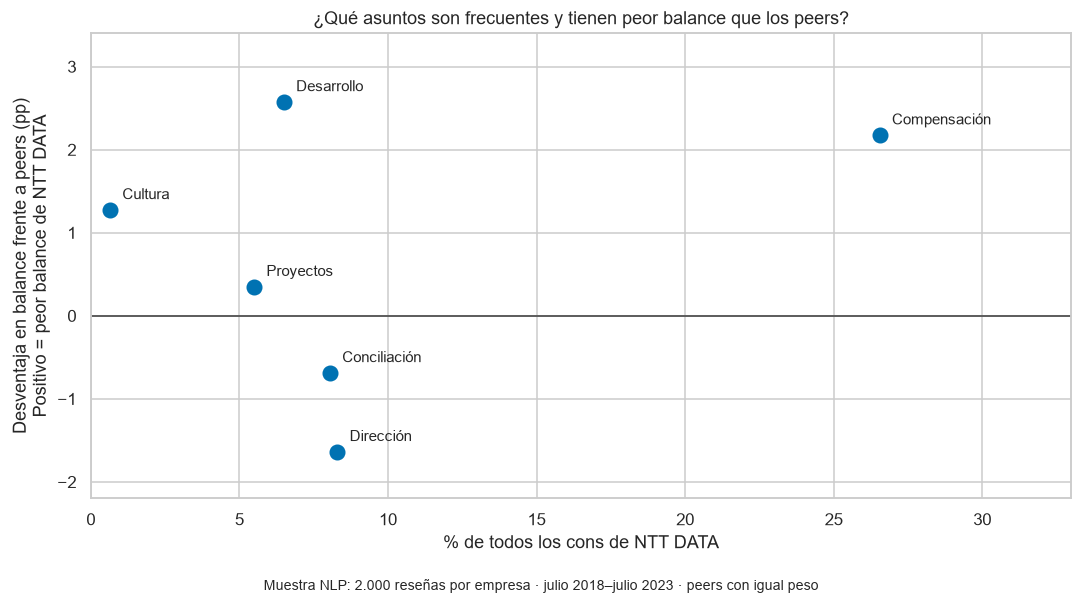

In [39]:
puntos_priorizacion = matriz_priorizacion.loc[matriz_priorizacion["Cons (n)"].gt(0)]
etiquetas_priorizacion = dict(zip(CATEGORIAS_NEGOCIO, [
    "Compensación", "Conciliación", "Cultura", "Dirección", "Desarrollo", "Proyectos", "Estabilidad"
]))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(puntos_priorizacion["Cons NTT (%)"], puntos_priorizacion["Desventaja (pp)"],
           s=90, color="#0072B2", zorder=3)
for categoria, fila in puntos_priorizacion.iterrows():
    ax.annotate(etiquetas_priorizacion[categoria],
                (fila["Cons NTT (%)"], fila["Desventaja (pp)"]),
                xytext=(8, 7), textcoords="offset points", fontsize=10)
ax.axhline(0, color="#555555", linewidth=1.2)
ax.set(xlabel="% de todos los cons de NTT DATA",
       ylabel="Desventaja en balance frente a peers (pp)\nPositivo = peor balance de NTT DATA",
       title="¿Qué asuntos son frecuentes y tienen peor balance que los peers?",
       xlim=(0, 33), ylim=(-2.2, 3.4))
fig.text(0.5, 0.01, "Muestra NLP: 2.000 reseñas por empresa · julio 2018–julio 2023 · peers con igual peso",
         ha="center", fontsize=9)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### Lectura de la matriz

- **Compensación:** primera prioridad para diagnóstico por su peso (26,55 %) y desventaja de balance (2,18 pp). El rating apenas baja y la recomendación sube: no hay corroboración consistente de peor valoración global.
- **Desarrollo:** segunda prioridad para un piloto: desventaja de 2,57 pp, con 6,50 % en cons. La diferencia procede sobre todo de menos pros (5,00 % frente a 6,96 %); rating y recomendación son casi iguales al resto.
- **Otros asuntos:** cultura solo tiene 13 casos y nueve opiniones; proyectos presenta una desventaja pequeña (0,35 pp). Dirección tiene menor rating y recomendación, pero mejor balance que peers. Ninguno justifica una tercera intervención prioritaria con esta evidencia.

## 12. Recomendaciones para RRHH

Proponemos **dos intervenciones acotadas**. Los plazos y métricas siguientes son propuestas para contrastar las hipótesis; no son efectos estimados por el análisis.

### 1. Revisar y explicar los criterios de compensación

**Evidencia:** 531 cons de compensación (26,55 %), frente al 21,94 % en peers; balance 2,18 pp peor. Entre antiguos también supera a peers (24,13 % frente a 20,17 %). Rating −0,046 y recomendación +3,81 pp frente al resto: la queja salarial no implica peor valoración global.

**Acción:** RRHH y Compensación deben contrastar bandas y criterios de revisión con datos internos y entrevistas; seleccionar un colectivo para un piloto de 90 días, comunicar criterios, fechas y responsables, y corregir los desajustes confirmados. Medir comprensión de los criterios y percepción de equidad antes y después; usar estos resultados para decidir su ampliación.

### 2. Hacer visible un itinerario de desarrollo por rol

**Evidencia:** 130 cons de desarrollo (6,50 % frente al 5,89 % en peers) y menos pros (5,00 % frente al 6,96 %); balance 2,57 pp peor. Rating −0,002 y recomendación −0,71 pp frente al resto: sin corroboración clara de peor valoración global. Entre antiguos, el peso coincide con peers (5,99 %).

**Acción:** RRHH y los responsables de equipo deben contrastar las necesidades internas y pilotar durante 90 días un itinerario por rol, con competencias para progresar, formación asignada y una conversación de desarrollo. Medir la proporción de participantes con plan acordado y la claridad percibida de las oportunidades antes y después; ampliar según los resultados.

## 13. Extra: tiempo y recomendación

### 13.1. Categorías antes de 2020 y desde 2020

Seleccionamos compensación y desarrollo por su prioridad, y conciliación como fortaleza. Usamos los cons de `df_nlp` con fecha, conservando las categorías conjuntas. Cada porcentaje se calcula sobre **todos los cons de su empresa y periodo**, incluidos los grupos de control; los peers tienen igual peso. Los periodos cubren julio de 2018–diciembre de 2019 y enero de 2020–julio de 2023: difieren en duración y composición. Δ es «desde − antes» en puntos porcentuales; la comparación es descriptiva.

In [40]:
CATEGORIAS_EXTRA = ["Compensación y beneficios", "Formación y desarrollo profesional", "Conciliación y flexibilidad"]
PERIODOS_EXTRA = ["Antes de 2020", "Desde 2020"]
base_extra_tiempo = df_nlp.loc[df_nlp["cons"].notna() & df_nlp["date_review"].notna()].copy()
base_extra_tiempo["periodo"] = base_extra_tiempo["date_review"].dt.year.lt(2020).map(
    {True: PERIODOS_EXTRA[0], False: PERIODOS_EXTRA[1]}
)
grupos_extra_tiempo = pd.MultiIndex.from_product([FIRMS, PERIODOS_EXTRA], names=["firm", "periodo"])
n_cons_periodo = base_extra_tiempo.groupby(["firm", "periodo"])["cons"].count().reindex(grupos_extra_tiempo, fill_value=0)
recuentos_periodo = pd.crosstab(
    [base_extra_tiempo["firm"], base_extra_tiempo["periodo"]], base_extra_tiempo["cons_categoria"]
).reindex(index=grupos_extra_tiempo, columns=equivalencias_topics.index, fill_value=0)
porcentajes_periodo = recuentos_periodo.div(n_cons_periodo, axis=0).mul(100)
cobertura_periodo = pd.DataFrame({
    "Cons (n)": n_cons_periodo,
    "Negocio (%)": porcentajes_periodo[CATEGORIAS_NEGOCIO].sum(axis=1, min_count=1),
    "Sin tema (%)": porcentajes_periodo["Sin tema"]
})
display(cobertura_periodo.unstack("periodo").reindex(FIRMS).rename(index=ETIQUETAS).round(2))

temporal_ntt = porcentajes_periodo.loc[TARGET, CATEGORIAS_EXTRA].reindex(PERIODOS_EXTRA).T.copy()
temporal_peers = porcentajes_periodo.loc[PEERS, CATEGORIAS_EXTRA].groupby(level="periodo").mean().reindex(PERIODOS_EXTRA).T
for datos in [temporal_ntt, temporal_peers]:
    datos["Δ (pp)"] = datos[PERIODOS_EXTRA[1]] - datos[PERIODOS_EXTRA[0]]
display(pd.concat({"NTT DATA": temporal_ntt, "Media peers": temporal_peers}, axis=1).round(2))

Cons (n)              Negocio (%)             \
periodo        Antes de 2020 Desde 2020 Antes de 2020 Desde 2020   
firm                                                               
NTT DATA                 315       1685         56.51      55.37   
Capgemini                251       1749         49.80      50.54   
Cognizant                293       1707         52.90      51.96   
Atos                     439       1561         48.75      49.71   
DXC Technology           426       1574         44.13      52.54   

                Sin tema (%)             
periodo        Antes de 2020 Desde 2020  
firm                                     
NTT DATA               27.94      25.58  
Capgemini              37.45      27.04  
Cognizant              28.67      28.76  
Atos                   32.80      26.59  
DXC Technology         34.74      27.89

NTT DATA                    \
periodo                            Antes de 2020 Desde 2020 Δ (pp)   
Categoría                                                            
Compensación y beneficios                  25.40      26.77   1.37   
Formación y desarrollo profesional          7.30       6.35  -0.95   
Conciliación y flexibilidad                 6.35       8.37   2.02   

                                     Media peers                    
periodo                            Antes de 2020 Desde 2020 Δ (pp)  
Categoría                                                           
Compensación y beneficios                  20.20      22.42   2.22  
Formación y desarrollo profesional          5.66       5.94   0.28  
Conciliación y flexibilidad                 6.76       7.41   0.65

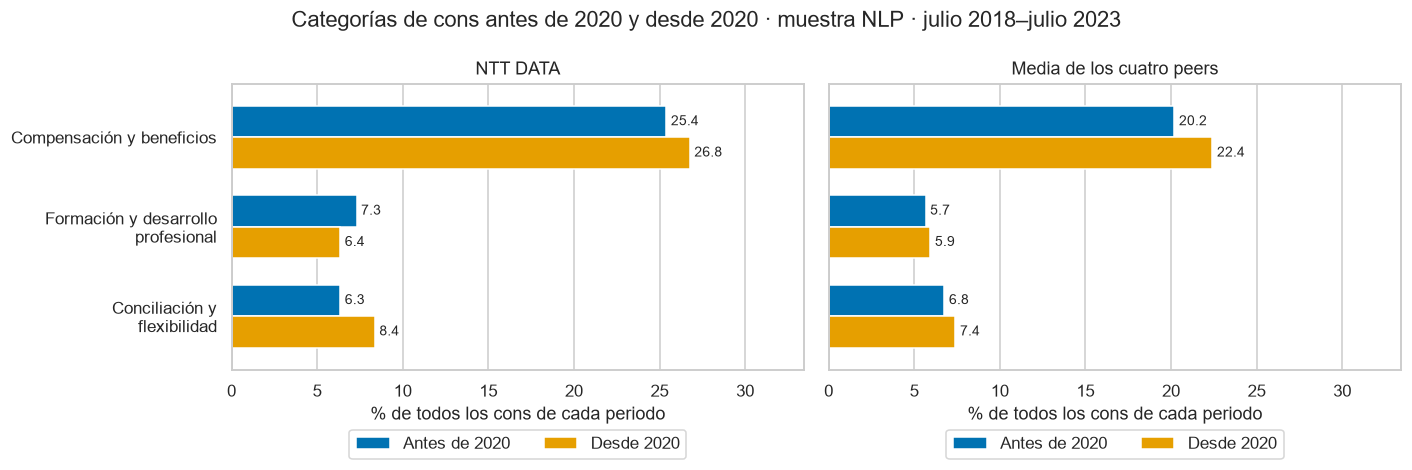

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
limite_extra_tiempo = 1.25 * max(temporal_ntt[PERIODOS_EXTRA].max().max(), temporal_peers[PERIODOS_EXTRA].max().max())
for ax, datos, titulo in zip(axes, [temporal_ntt, temporal_peers], ["NTT DATA", "Media de los cuatro peers"]):
    datos[PERIODOS_EXTRA].rename(index=lambda categoria: fill(categoria, 26)).plot.barh(
        ax=ax, color=["#0072B2", "#E69F00"], width=0.7
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
    ax.set(title=titulo, xlabel="% de todos los cons de cada periodo", ylabel="", xlim=(0, limite_extra_tiempo))
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
axes[0].invert_yaxis()
fig.suptitle("Categorías de cons antes de 2020 y desde 2020 · muestra NLP · julio 2018–julio 2023")
plt.tight_layout()
plt.show()

### Interpretación temporal

- **Compensación:** pasa del 25,40 % al 26,77 % de cons en NTT DATA; en peers, del 20,20 % al 22,42 %. Sigue por encima de peers en ambos periodos, aunque la diferencia se reduce.
- **Desarrollo:** baja del 7,30 % al 6,35 %, mientras peers pasa del 5,66 % al 5,94 %. Aquí medimos presencia en cons, no el balance que motivó su priorización.
- **Conciliación:** aumenta del 6,35 % al 8,37 % (+2,02 pp), frente a +0,65 pp en peers. Una fortaleza en el balance agregado puede coexistir con más cons en el periodo posterior.

La cobertura de negocio varía entre periodos, especialmente en DXC (44,13 % frente al 52,54 %). Las variaciones pueden reflejar cambios de composición y cobertura; no demuestran un efecto de 2020 ni diferencias estadísticamente significativas.

### 13.2. Categorías según recomendación

Comparamos los cons de NTT DATA entre «Sí», «No» y «Sin opinión». Cada porcentaje usa **todos los cons del grupo**; «Sin opinión» se mantiene separado. Δ es «No − Sí» en puntos porcentuales. Este desglose complementa el apartado 9 mostrando qué asuntos aparecen dentro de cada grupo; reutiliza las mismas reseñas y no aporta evidencia independiente.

In [42]:
RECOMENDACIONES_EXTRA = ["Sí", "No", "Sin opinión"]
base_extra_recomendacion = df_nlp.loc[df_nlp["firm"].eq(TARGET) & df_nlp["cons"].notna()]
n_cons_recomendacion = base_extra_recomendacion.groupby("recomienda")["cons"].count().reindex(RECOMENDACIONES_EXTRA, fill_value=0)
recuentos_recomendacion = pd.crosstab(
    base_extra_recomendacion["recomienda"], base_extra_recomendacion["cons_categoria"]
).reindex(index=RECOMENDACIONES_EXTRA, columns=equivalencias_topics.index, fill_value=0)
porcentajes_recomendacion = recuentos_recomendacion.div(n_cons_recomendacion, axis=0).mul(100)
cobertura_recomendacion = pd.DataFrame({
    "Cons (n)": n_cons_recomendacion,
    "Negocio (%)": porcentajes_recomendacion[CATEGORIAS_NEGOCIO].sum(axis=1, min_count=1),
    "Sin tema (%)": porcentajes_recomendacion["Sin tema"]
})
display(cobertura_recomendacion.round(2))
recomendacion_categorias = porcentajes_recomendacion[CATEGORIAS_EXTRA].T.copy()
recomendacion_categorias["Δ No − Sí (pp)"] = recomendacion_categorias["No"] - recomendacion_categorias["Sí"]
display(recomendacion_categorias.round(2))

,Cons (n),Negocio (%),Sin tema (%)
recomienda,,,
Sí,949,55.64,23.50
No,407,55.04,30.96
Sin opinión,644,55.75,26.40


recomienda,Sí,No,Sin opinión,Δ No − Sí (pp)
Categoría,,,,
Compensación y beneficios,27.08,23.59,27.64,-3.49
Formación y desarrollo profesional,6.43,6.63,6.52,0.21
Conciliación y flexibilidad,9.06,4.91,8.54,-4.15


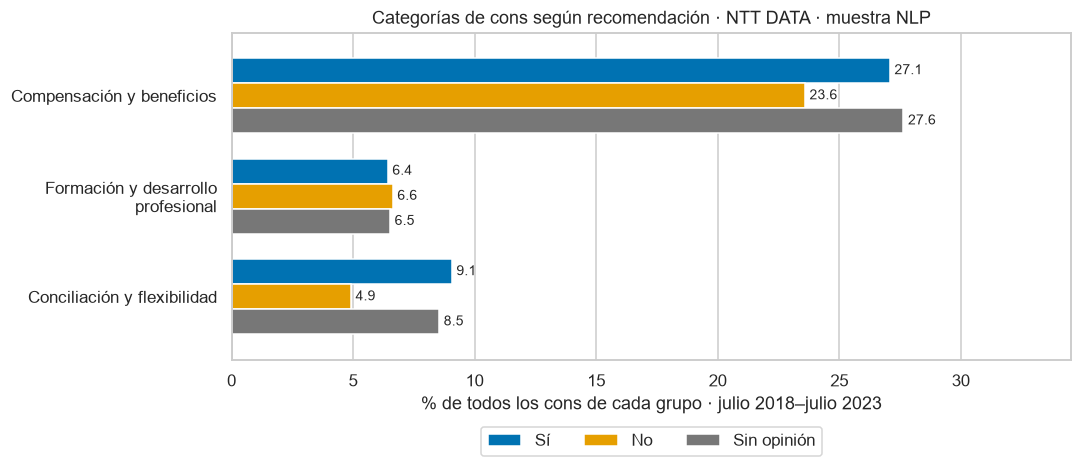

In [43]:
fig, ax = plt.subplots(figsize=(10, 4.5))
recomendacion_categorias[RECOMENDACIONES_EXTRA].rename(index=lambda categoria: fill(categoria, 28)).plot.barh(
    ax=ax, color=["#0072B2", "#E69F00", "#777777"], width=0.75
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
ax.invert_yaxis()
ax.set(title="Categorías de cons según recomendación · NTT DATA · muestra NLP",
       xlabel="% de todos los cons de cada grupo · julio 2018–julio 2023", ylabel="",
       xlim=(0, 1.25 * recomendacion_categorias[RECOMENDACIONES_EXTRA].max().max()))
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.tight_layout()
plt.show()

### Interpretación por recomendación

Compensación aparece en el 27,08 % de cons de quienes recomiendan y en el 23,59 % de quienes no; desarrollo tiene pesos próximos (6,43 % y 6,63 %). Estas categorías no están especialmente concentradas entre quienes no recomiendan, en línea con el contraste del apartado 9.

Conciliación también pesa más entre quienes recomiendan (9,06 % frente al 4,91 %): una queja concreta puede coexistir con una opinión global favorable. Entre quienes no recomiendan queda un 30,96 % de cons sin tema, frente al 23,50 % del grupo «Sí»; esto limita identificar todos los asuntos asociados a cada grupo.

## 14. Limitaciones y conclusiones

### Conclusiones

**Fortalezas:** la conciliación y flexibilidad destaca en la muestra, con un 21,00 % de pros y un balance de +12,95 pp. Su gap de +0,69 pp frente a peers indica una ventaja descriptiva modesta. Cultura también presenta un balance positivo, aunque inferior al de los competidores: una fortaleza interna no implica necesariamente una ventaja frente al mercado.

**Áreas de mejora:** compensación reúne el 26,55 % de cons, frente al 21,94 % de peers, y un gap de balance de −2,18 pp. Por su frecuencia y desventaja relativa, es la primera prioridad para diagnóstico. Desarrollo tiene el peor gap (−2,57 pp), principalmente por menos menciones en pros (5,00 % frente al 6,96 %). Esto orienta a explorar tanto las oportunidades disponibles como su visibilidad para los empleados.

**Contraste con rating y recomendación:** las quejas de compensación no se acompañan de una peor valoración global consistente: el rating es próximo al resto y la recomendación es mayor. Desarrollo presenta valores casi iguales al resto. Por tanto, estos asuntos son hipótesis de mejora, sin evidencia suficiente para afirmar que expliquen una menor satisfacción general. Dirección sí combina menor rating y recomendación, pero su balance frente a peers es mejor; merece atención como señal interna, sin presentarla como desventaja competitiva.

**Empleados antiguos:** compensación aparece más que entre antiguos de peers (24,13 % frente al 20,17 %), pero pesa todavía más entre actuales de NTT DATA (27,67 %). Es un asunto compartido por ambos grupos. Dirección aumenta entre antiguos respecto a actuales, aunque queda por debajo de antiguos de peers. Estos patrones ayudan a enfocar entrevistas de salida, sin identificar por sí solos los motivos de abandono.

**Tiempo y recomendación:** compensación mantiene mayor presencia en cons que peers en ambos periodos, mientras conciliación aumenta desde 2020. Las quejas de compensación aparecen también entre quienes recomiendan y desarrollo apenas difiere entre «Sí» y «No». El extra aporta matices para el seguimiento, manteniendo el enfoque de diagnóstico y pilotos.

**Implicación para RRHH:** la evidencia respalda comenzar con dos intervenciones acotadas: revisar y explicar los criterios de compensación, y hacer visible un itinerario de desarrollo por rol. El contraste interno y el seguimiento de los pilotos deben determinar qué cambios ampliar; el análisis no demuestra que estas acciones vayan a mejorar la retención o las valoraciones de Glassdoor.

**Limitaciones:** Glassdoor tiene autoselección y posibles diferencias geográficas entre empresas. El análisis es histórico (2018–2023) y la muestra NLP de 2.000 reseñas por empresa no representa a toda la plantilla. Sentimiento, topics y asignación manual pueden cometer errores; las categorías mixtas y los textos sin tema limitan la cobertura. Los porcentajes son relativos y las asociaciones no prueban causalidad.

**Siguiente paso:** contrastar las hipótesis con encuestas internas y entrevistas de salida, y evaluar los dos pilotos propuestos antes de ampliarlos.